**Fraud Detection Project**

Import libraries and Load data

In [444]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score,confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [445]:
df= pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/raw data/synthetic_fraud_dataset.csv')

In [446]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


Data Cleaning

In [447]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [448]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [449]:
for columna in df.columns:
    if df[columna].dtypes == 'O':
        print(f"\n\n\nColumna {columna} \n {df[columna].value_counts()}")




Columna transaction_type 
 transaction_type
POS       2568
ATM       2529
QR        2506
Online    2397
Name: count, dtype: int64



Columna merchant_category 
 merchant_category
Food           2023
Travel         2015
Electronics    2007
Clothing       1982
Grocery        1973
Name: count, dtype: int64



Columna country 
 country
US    2050
FR    2027
UK    1965
DE    1930
TR    1928
NG     100
Name: count, dtype: int64


In [450]:
df['hour'].value_counts()

hour
13    584
17    564
6     560
10    560
21    560
16    555
15    553
20    548
7     545
12    541
9     541
23    539
19    539
18    536
11    534
8     530
14    522
22    496
4     117
3      18
0      16
2      16
5      15
1      11
Name: count, dtype: int64

In [451]:
col_drop= ['transaction_id', 'user_id']

In [452]:
df = df.drop(columns=col_drop, axis=1)

In [453]:
df

,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0
...,...,...,...,...,...,...,...,...
9995,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0


In [454]:
df['amount'].value_counts().sort_values(ascending=True)

amount
96.681684       1
63.992870       1
88.509815       1
11.670064       1
202.995895      1
             ... 
40.381822       1
204.318771      1
22.168429      41
10.000000      92
1.000000      231
Name: count, Length: 9639, dtype: int64

In [455]:
df['is_fraud'].value_counts()

is_fraud
0    9500
1     500
Name: count, dtype: int64

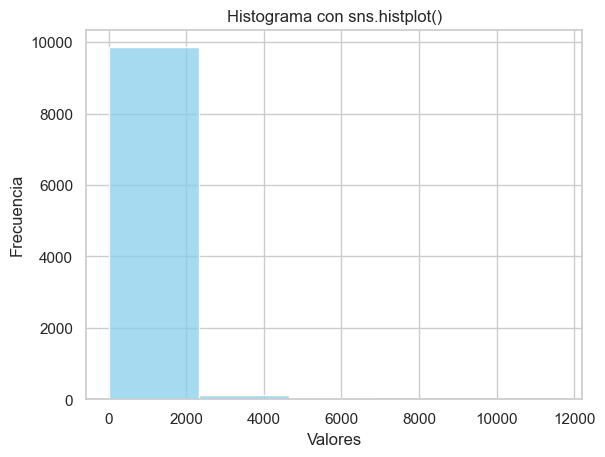

In [456]:
data=df['amount']
sns.histplot(data, bins=5, color='skyblue') #observa variando el valor de bins, o simplemente no ponerlos
plt.title('Histograma con sns.histplot()')
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.show()

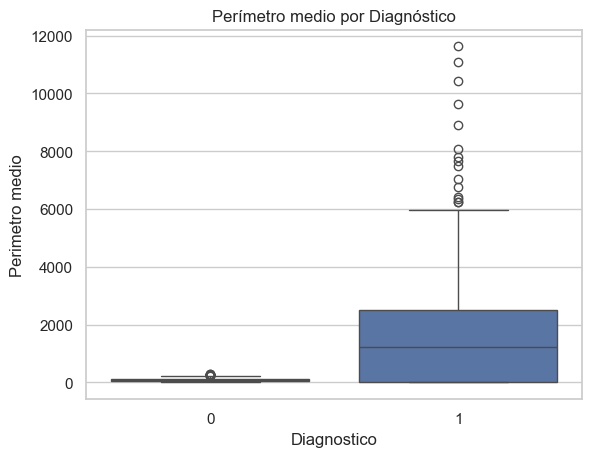

In [457]:
sns.set(style='whitegrid')
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.xlabel('Diagnostico')
plt.ylabel('Perimetro medio')
plt.title('Perímetro medio por Diagnóstico')
plt.show()



In [458]:

# Filtrar solo las transacciones fraudulentas
fraud_df = df[df['is_fraud'] == 1]

# Calcular Q1, Q3 y rango intercuartílico
Q1 = fraud_df['amount'].quantile(0.25)
Q3 = fraud_df['amount'].quantile(0.75)
IQR = Q3 - Q1

# Límites para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = fraud_df[(fraud_df['amount'] < lower_bound) | (fraud_df['amount'] > upper_bound)]

outliers


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
1249,7801.156913,ATM,Travel,TR,15,0.921046,0.747134,1
2542,9647.703212,POS,Travel,NG,23,0.733071,0.778173,1
3590,11628.213881,POS,Food,TR,23,0.951310,0.942084,1
4172,7504.225429,POS,Clothing,TR,12,0.930454,0.933918,1
4221,6253.210886,QR,Travel,DE,1,0.958864,0.741658,1
4665,7029.217542,Online,Grocery,UK,6,0.930219,0.716167,1
5028,7653.453836,Online,Grocery,TR,21,0.935627,0.721351,1
5678,6256.990937,QR,Grocery,FR,15,0.789041,0.948139,1
5680,10430.158835,ATM,Travel,DE,8,0.975839,0.726795,1
6284,6770.958804,Online,Grocery,US,6,0.851272,0.788905,1


In [459]:
df_outlier = df

Q1 = df_outlier['amount'].quantile(0.25)
Q3 = df_outlier['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outliers en general
outliers_fulldf = df_outlier[(df_outlier['amount'] < lower_bound) | (df_outlier['amount'] > upper_bound)]

outliers_fulldf


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
23,4284.177967,ATM,Food,TR,12,0.737854,0.731071,1
84,1148.378114,POS,Travel,DE,19,0.945709,0.835616,1
87,952.547905,QR,Travel,UK,20,0.783611,0.985521,1
89,2865.421641,ATM,Food,TR,13,0.834843,0.904304,1
...,...,...,...,...,...,...,...,...
9711,461.937955,QR,Food,NG,23,0.816233,0.781520,1
9787,1455.533469,QR,Food,TR,4,0.893687,0.957413,1
9794,2231.990705,QR,Clothing,UK,7,0.750121,0.727340,1
9856,1381.201430,POS,Food,US,19,0.940389,0.818065,1


In [460]:
fraud_df = outliers_fulldf[outliers_fulldf['is_fraud'] == 1]

In [461]:
fraud_df

,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
23,4284.177967,ATM,Food,TR,12,0.737854,0.731071,1
84,1148.378114,POS,Travel,DE,19,0.945709,0.835616,1
87,952.547905,QR,Travel,UK,20,0.783611,0.985521,1
89,2865.421641,ATM,Food,TR,13,0.834843,0.904304,1
...,...,...,...,...,...,...,...,...
9711,461.937955,QR,Food,NG,23,0.816233,0.781520,1
9787,1455.533469,QR,Food,TR,4,0.893687,0.957413,1
9794,2231.990705,QR,Clothing,UK,7,0.750121,0.727340,1
9856,1381.201430,POS,Food,US,19,0.940389,0.818065,1


Feature Engineering

Add an identifier to the outliers found in the 'amount' column

In [462]:
from scipy.stats import zscore

# Calcular Z-Score de la columna amount
df['zscore_amount'] = zscore(df['amount'])

# Crear un feature de severidad: solo positivos si es outlier
def zscore_severity(z):
    if abs(z) > 3:  # umbral típico para considerar outlier
        return abs(z) - 3  # cuánto se pasa del límite
    else:
        return 0  # no es outlier

df['outlier_severity_z'] = df['zscore_amount'].apply(zscore_severity)

Transform categorical columns with get_dummies

In [463]:
categorical_cols = ['transaction_type', 'merchant_category', 'country']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

df_encoded

,amount,hour,device_risk_score,ip_risk_score,is_fraud,zscore_amount,outlier_severity_z,transaction_type_ATM,transaction_type_Online,transaction_type_POS,...,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_DE,country_FR,country_NG,country_TR,country_UK,country_US
0,4922.587542,12,0.992347,0.947908,1,8.924481,5.924481,True,False,False,...,False,False,False,True,False,False,False,True,False,False
1,48.018303,21,0.168571,0.224057,0,-0.244769,0.000000,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,136.881960,14,0.296127,0.125058,0,-0.077613,0.000000,False,True,False,...,False,False,False,True,False,False,False,True,False,False
3,80.534719,23,0.124801,0.159243,0,-0.183604,0.000000,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,120.041158,16,0.098129,0.027542,0,-0.109291,0.000000,False,True,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58.366442,12,0.066366,0.086344,0,-0.225304,0.000000,False,False,True,...,False,False,False,False,True,False,False,False,False,False
9996,139.502160,13,0.119014,0.285680,0,-0.072684,0.000000,False,False,True,...,False,False,False,True,True,False,False,False,False,False
9997,71.012122,8,0.119204,0.262262,0,-0.201517,0.000000,False,True,False,...,False,False,False,True,False,False,False,True,False,False
9998,21.031405,12,0.027088,0.295243,0,-0.295532,0.000000,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [464]:
dummy_cols = df_encoded.select_dtypes(include='bool').columns

# Convertir a int
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

In [465]:
df_encoded

,amount,hour,device_risk_score,ip_risk_score,is_fraud,zscore_amount,outlier_severity_z,transaction_type_ATM,transaction_type_Online,transaction_type_POS,...,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_DE,country_FR,country_NG,country_TR,country_UK,country_US
0,4922.587542,12,0.992347,0.947908,1,8.924481,5.924481,1,0,0,...,0,0,0,1,0,0,0,1,0,0
1,48.018303,21,0.168571,0.224057,0,-0.244769,0.000000,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,136.881960,14,0.296127,0.125058,0,-0.077613,0.000000,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,80.534719,23,0.124801,0.159243,0,-0.183604,0.000000,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,120.041158,16,0.098129,0.027542,0,-0.109291,0.000000,0,1,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58.366442,12,0.066366,0.086344,0,-0.225304,0.000000,0,0,1,...,0,0,0,0,1,0,0,0,0,0
9996,139.502160,13,0.119014,0.285680,0,-0.072684,0.000000,0,0,1,...,0,0,0,1,1,0,0,0,0,0
9997,71.012122,8,0.119204,0.262262,0,-0.201517,0.000000,0,1,0,...,0,0,0,1,0,0,0,1,0,0
9998,21.031405,12,0.027088,0.295243,0,-0.295532,0.000000,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [466]:
df_encoded.corr()['is_fraud'].sort_values(ascending=False)

is_fraud                         1.000000
device_risk_score                0.871989
ip_risk_score                    0.870738
zscore_amount                    0.638435
amount                           0.638435
country_NG                       0.438086
outlier_severity_z               0.417239
transaction_type_ATM             0.012192
merchant_category_Clothing       0.011395
transaction_type_Online          0.006610
merchant_category_Travel         0.006005
merchant_category_Electronics   -0.002692
merchant_category_Grocery       -0.004208
transaction_type_QR             -0.005612
country_US                      -0.006251
merchant_category_Food          -0.010451
transaction_type_POS            -0.013023
country_UK                      -0.015300
country_TR                      -0.024890
country_FR                      -0.031216
country_DE                      -0.031972
hour                            -0.181448
Name: is_fraud, dtype: float64

In [467]:
cols_to_remove = ['device_risk_score', 'ip_risk_score', 'zscore_amount']

df_encoded = df_encoded.drop(columns=cols_to_remove)

Model Training

In [468]:
#Split Dataset 

X = df_encoded.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [469]:
#Scale numeric columns

scaler = StandardScaler()

cols_to_scale = ['amount', 'hour']


X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])



In [470]:
#Train the Baseline Model - Logistic Regression


model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [471]:
y_pred = model.predict(X_test)

print("Métricas de clasificación:\n")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:\n")
print(confusion_matrix(y_test, y_pred))

Métricas de clasificación:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2838
           1       0.73      0.80      0.76       162

    accuracy                           0.97      3000
   macro avg       0.86      0.89      0.88      3000
weighted avg       0.97      0.97      0.97      3000

Matriz de confusión:

[[2790   48]
 [  32  130]]


In [472]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("Accuracy por fold:", scores)
print("Accuracy promedio:", np.mean(scores))



# Obtener predicciones en cross-validation
y_pred_cv = cross_val_predict(model, X, y, cv=skf)

print(classification_report(y, y_pred_cv))

Accuracy por fold: [0.9795 0.9715 0.984  0.978  0.9855]
Accuracy promedio: 0.9797
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9500
           1       0.80      0.78      0.79       500

    accuracy                           0.98     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.98      0.98      0.98     10000



The target class has to be balanced because the Baseline model predicted almots 100% of the No fraud transdactions because the classes are desbalanced

In [473]:
#Train the Logistic Regression Model with SMOTE data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

X_train_res[cols_to_scale] = scaler.fit_transform(X_train_res[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])



model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')

model_smote.fit(X_train_res, y_train_res)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [474]:
#Evaluate the SMOTE model
y_pred = model_smote.predict(X_test)

print("Métricas de clasificación:\n")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:\n")
print(confusion_matrix(y_test, y_pred))

Métricas de clasificación:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2838
           1       1.00      0.71      0.83       162

    accuracy                           0.98      3000
   macro avg       0.99      0.85      0.91      3000
weighted avg       0.98      0.98      0.98      3000

Matriz de confusión:

[[2838    0]
 [  47  115]]


In [475]:
# Train and XGBoost Model with SMOTE data

import xgboost as xgb

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_lambda=1.0,
    scale_pos_weight=1,   
    random_state=42,
    tree_method="hist"   
)


In [476]:
#Training
model_xgb.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [477]:
y_pred_xgb = model_xgb.predict(X_test)

print("Métricas de clasificación:")
print(classification_report(y_test, y_pred_xgb))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

Métricas de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2838
           1       0.99      0.96      0.97       162

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000

Matriz de confusión:
[[2837    1]
 [   7  155]]
